# TUGAS AKHIR

* Nama: Joice Ocrisa 
* NRP: 5003221066

## Harga Saham BMRI

In [3]:
import sys
import os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

from models.tuning_lstm import train_lstm_tuning
from models import LSTMModel, FEDformer_Model
from utils.data_loader import load_stock_data, prepare_univariate_data
from utils.evaluation import calculate_metrics, plot_predictions, plot_comparison, print_metrics


In [4]:
# Configuration 
BANK_CODE = 'BMRI'  
SEQ_LEN = 30  # Sequence length (look back period)
PRED_LEN = 1  # Prediction length
BATCH_SIZE = 32
EPOCHS = 50 #UP TO 100
LEARNING_RATE = 0.001

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


Using device: cpu


### Data

In [5]:
# date 
start_date = '2004-06-30'
end_date = '2025-06-30'

# get data
df = load_stock_data(BANK_CODE)
df = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)]
print(f"\nUkuran data: {df.shape}")
print("Tanggal awal:", start_date)
print("Tanggal akhir:", end_date)
print("\nBerikut adalah 5 baris pertama data:")
df.tail()

c:\Users\User\Documents\AA - TA\tugas-akhir\indonesia-bank-stock-dataset\datasets\BMRI\BMRI.csv

Ukuran data: (5179, 8)
Tanggal awal: 2004-06-30
Tanggal akhir: 2025-06-30

Berikut adalah 5 baris pertama data:


,Close,Date,High,Kode,Low,Nama,Open,Volume
5303,4920.0,2025-06-23,4930.0,BMRI,4800.0,Bank Mandiri (Persero) Tbk.,4870.0,119439200.0
5304,5025.0,2025-06-24,5125.0,BMRI,5025.0,Bank Mandiri (Persero) Tbk.,5050.0,126563900.0
5305,4880.0,2025-06-25,5050.0,BMRI,4880.0,Bank Mandiri (Persero) Tbk.,5025.0,139963400.0
5306,5025.0,2025-06-26,5025.0,BMRI,4910.0,Bank Mandiri (Persero) Tbk.,4950.0,94704500.0
5307,4880.0,2025-06-30,5050.0,BMRI,4880.0,Bank Mandiri (Persero) Tbk.,5050.0,220479900.0


In [6]:
# Missing Value 

missing_values = df.isnull().sum()
print(f"Missing values:\n{missing_values}")
df = df.dropna(subset=['Close'])


Missing values:
Close     0
Date      0
High      0
Kode      0
Low       0
Nama      0
Open      0
Volume    0
dtype: int64


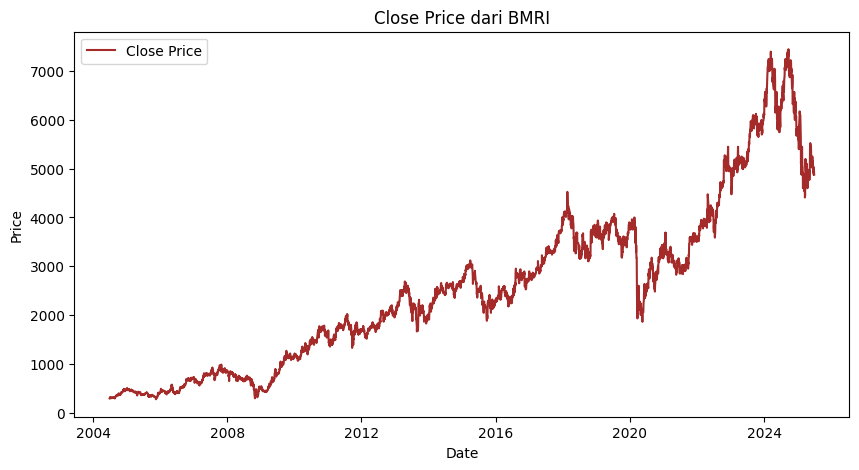

In [11]:
# Time Series Plot

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], label = 'Close Price', color = 'brown')
plt.title('Close Price dari ' + BANK_CODE)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [7]:
# Split Data 

X_train, y_train, X_val, y_val, X_test, y_test, scaler = prepare_univariate_data(df, feature_col='Close', seq_len=SEQ_LEN)
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}, y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (3604, 30, 1), y_train shape: (3604, 1)
X_val shape: (772, 30, 1), y_val shape: (772, 1)
X_test shape: (773, 30, 1), y_test shape: (773, 1)


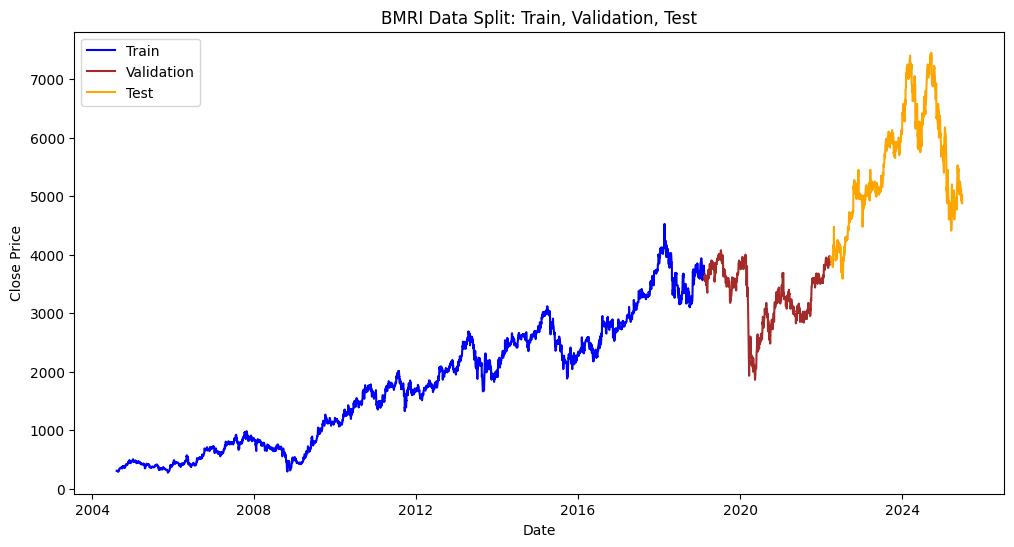

In [8]:
# Plot after split data
Train_size = len(X_train)
Val_size = len(X_val)
Test_size = len(X_test)

Date = df['Date'].values

# Define date for train val and test
idx_train_start = SEQ_LEN - 1
idx_train_end = idx_train_start + Train_size
idx_val_start = idx_train_end 
idx_val_end = idx_val_start + Val_size
idx_test_start = idx_val_end
idx_test_end = idx_test_start + Test_size

train_dates = Date[idx_train_start:idx_train_end]
val_dates = Date[idx_val_start:idx_val_end]
test_dates = Date[idx_test_start:idx_test_end]

# Ensure dates and target lengths match
target_train = y_train[:,0] if y_train.ndim > 1 else y_train
target_val = y_val[:,0] if y_val.ndim > 1 else y_val
target_test = y_test[:,0] if y_test.ndim > 1 else y_test

# Ensure target 1D for plotting
train_inv = scaler.inverse_transform(target_train.reshape(-1, 1)).flatten()
val_inv = scaler.inverse_transform(target_val.reshape(-1, 1)).flatten()
test_inv = scaler.inverse_transform(target_test.reshape(-1, 1)).flatten()

# To avoid if there is a mismatch shape
train_n = min(len(train_dates), len(train_inv))
val_n = min(len(val_dates), len(val_inv))
test_n = min(len(test_dates), len(test_inv))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train_dates[:train_n], train_inv[:train_n], label='Train', color='blue')
plt.plot(val_dates[:val_n], val_inv[:val_n], label='Validation', color='brown')
plt.plot(test_dates[:test_n], test_inv[:test_n], label='Test', color='orange')

plt.title(BANK_CODE + ' Data Split: Train, Validation, Test')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [9]:
# Buat data yang sesuai dengan Data Loader
class stockdataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = stockdataset(X_train, y_train)
val_dataset = stockdataset(X_val, y_val)    
test_dataset = stockdataset(X_test, y_test)

# Gunakan DataLoader untuk batching
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)    

## **LSTM Model**

### Train-Validation LSTM 

In [ ]:
# LSTMModel 
lstm_model = LSTMModel(
    input_size = 1, 
    hidden_size=64, 
    num_layers = 2, 
    output_size = PRED_LEN, 
    dropout=0.2
).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

# menurunkan learning rate secara bertahap selama training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# training loop
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        # X_batch = X_batch.to(DEVICE)
        # y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = lstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print("LSTM Training Complete!")

### Tuning Hyperparameter LSTM

In [ ]:
# List Hyperparameter
dropout_list = [0.1, 0.2, 0.3]
lr_list = [1e-1, 1e-2, 1e-3]
batch_size_list = [32, 64, 128]

In [ ]:
results = []

for dropout, lr, batch_size in itertools.product(
        dropout_list, lr_list, batch_size_list):

    val_loss = train_lstm_tuning(dropout, lr, batch_size, train_dataset, val_dataset, DEVICE)
    results.append({
        'dropout': dropout,
        'learning_rate': lr,
        'batch_size': batch_size,
        'val_loss': val_loss
    })
    print(f"Dropout={dropout}, LR={lr}, Batch={batch_size}, Val Loss={val_loss:.6f}")

best_config = min(results, key=lambda x: x['val_loss'])

print("\n\nBest Hyperparameter Configuration:")
print(best_config)

### Training Validation with Best Hyperparameter

In [10]:
SEQ_LEN = 30  
PRED_LEN = 1  
EPOCHS = 100 
BATCH_SIZE = 32
LEARNING_RATE = 0.001
dropout = 0.2

# LSTMModel 
lstm_model = LSTMModel(
    input_size = 1, 
    hidden_size=64, 
    num_layers = 2, 
    output_size = PRED_LEN, 
    dropout=dropout
).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# training loop
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = lstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("LSTM Training Complete!")

Epoch [1/100] | Train Loss: 0.008780 | Val Loss: 0.000486
Epoch [2/100] | Train Loss: 0.000231 | Val Loss: 0.000478
Epoch [3/100] | Train Loss: 0.000209 | Val Loss: 0.000462
Epoch [4/100] | Train Loss: 0.000194 | Val Loss: 0.000470
Epoch [5/100] | Train Loss: 0.000198 | Val Loss: 0.000432
Epoch [6/100] | Train Loss: 0.000181 | Val Loss: 0.000422
Epoch [7/100] | Train Loss: 0.000174 | Val Loss: 0.000423
Epoch [8/100] | Train Loss: 0.000197 | Val Loss: 0.000489
Epoch [9/100] | Train Loss: 0.000164 | Val Loss: 0.000505
Epoch [10/100] | Train Loss: 0.000167 | Val Loss: 0.000636
Epoch [11/100] | Train Loss: 0.000160 | Val Loss: 0.000368
Epoch [12/100] | Train Loss: 0.000143 | Val Loss: 0.000339
Epoch [13/100] | Train Loss: 0.000146 | Val Loss: 0.000501
Epoch [14/100] | Train Loss: 0.000141 | Val Loss: 0.000334
Epoch [15/100] | Train Loss: 0.000138 | Val Loss: 0.000300
Epoch [16/100] | Train Loss: 0.000149 | Val Loss: 0.000388
Epoch [17/100] | Train Loss: 0.000140 | Val Loss: 0.000379
Epoch 

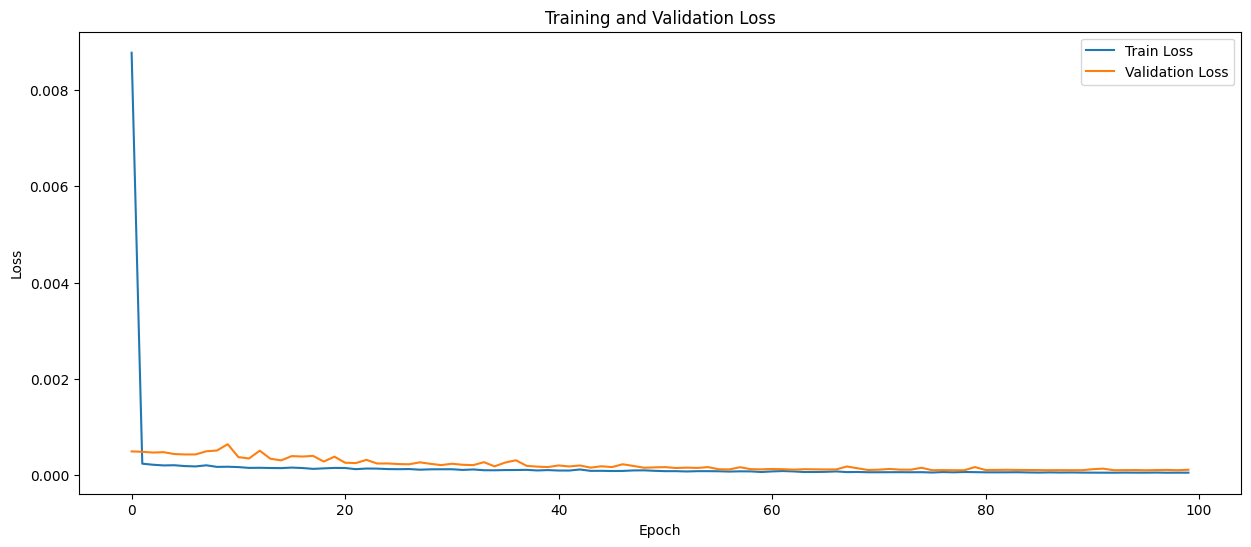

In [11]:
# Plot training and validation loss
plt.figure(figsize=(15, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [12]:
# Pengujian Model 
lstm_model.eval()

lstm_predictions = []
y_true_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        lstm_out = lstm_model(X_batch)
        lstm_out = lstm_out.cpu().numpy().flatten()

        lstm_predictions.append(lstm_out)
        y_true_list.append(y_batch.cpu().numpy().flatten())

lstm_pred = np.concatenate(lstm_predictions)
y_true = np.concatenate(y_true_list)

if scaler is not None:
    lstm_pred = scaler.inverse_transform(
        lstm_pred.reshape(-1, 1)
    ).flatten()

    y_true = scaler.inverse_transform(
        y_true.reshape(-1, 1)
    ).flatten()

In [13]:
# Calculate metrics
lstm_metrics = calculate_metrics(y_true, lstm_pred)

print_metrics(lstm_metrics, "LSTM")


LSTM Metrics:
----------------------------------------
MAE       : 210.1245
MSE       : 71882.8359
RMSE      : 268.1097
MAPE      : 3.5069%
R2        : 0.9200
----------------------------------------


## **FEDformer Model**

### Train-Validation FEDformer